# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8495,2.3270,216.9600,2,2
ethanol,46.07,2.3827,3.1771,198.24,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_held,0.054
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
glycine_held,H,glycine_held,e,2598.06,0.0393 
ethanol,H,glycine_held,e,2625.73,0.034406
ethanol,e,glycine_held,H,2625.73,0.034406
"""
components = ["ethanol", "glycine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[198.24 196.18988698545704; 196.18988698545704 216.96]
[3.1771e-10 2.75205e-10; 2.75205e-10 2.327e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2653.4, 2625.73, 2625.73, 2598.06]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.032384, 0.034406, 0.034406, 0.0393]
kij = 0.05400000000000005
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          0.000196511
   2 │      288.512        0.000440534
   3 │      307.025        0.000895203
   4 │      325.538        0.00167909
   5 │      344.05         0.00294781
   6 │      362.562        0.00489686
   7 │      381.075        0.00776272
   8 │      399.587        0.0118207
   9 │      418.1          0.0173758
  10 │      436.612        0.0247361
  11 │      455.125        0.03414
  12 │      473.638        0.0455259
  13 │      492.15         0.0574391
  14 │      510.662      NaN
  15 │      529.175      NaN
  16 │      547.688        0.34931
  17 │      566.2          0.464475
  18 │      584.712        0.502151
  19 │      603.225        0.59689
  20 │      621.737        0.742145
  21 │      640.25         0.833614
  22 │      658.762        0.909992
  23 │      677.275      NaN
  24 │

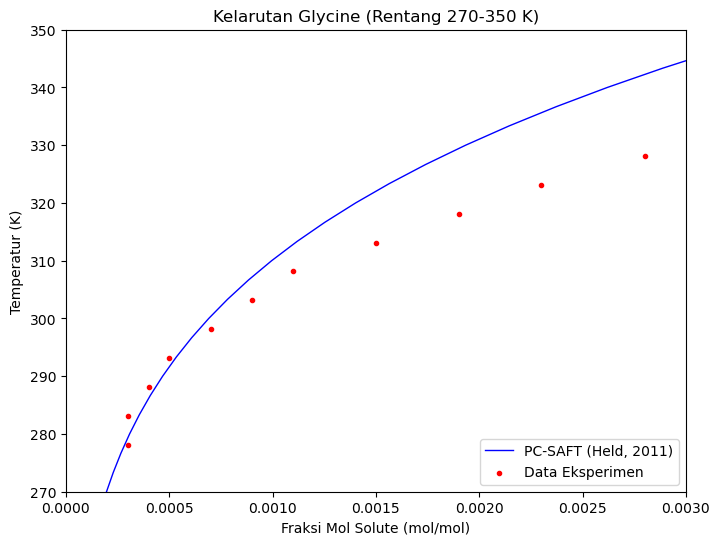

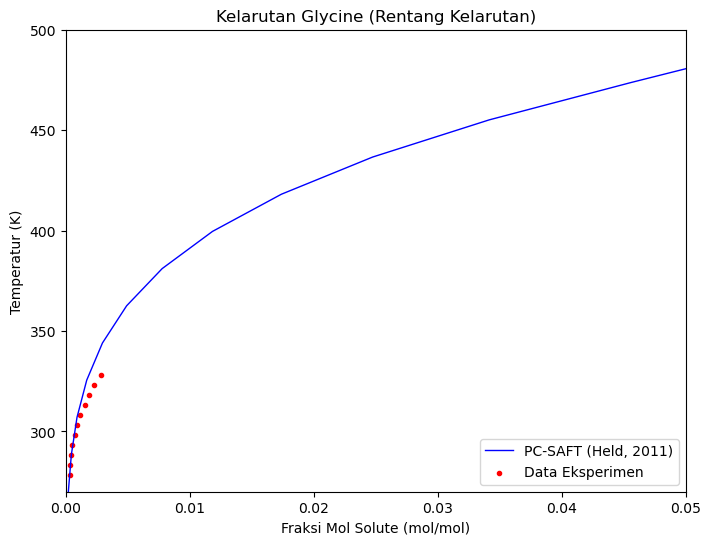

In [12]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_etanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.003)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270.,model1.solid.params.Tm[2], 25)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.05)
    plt.ylim(270.0, 500.)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [6]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [7]:
aard_p   = calculate_AAD(model1, "sol_glycine_etanol.csv", solubility_held)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000284      5.2757  
283.1500    0.000300      0.000353      17.5150 
288.1500    0.000400      0.000434      8.5158  
293.1500    0.000500      0.000531      6.1234  
298.1500    0.000700      0.000644      7.9612  
303.1500    0.000900      0.000777      13.6362 
308.1500    0.001100      0.000932      15.2671 
313.1500    0.001500      0.001111      25.9157 
318.1500    0.001900      0.001318      30.6467 
323.1500    0.002300      0.001554      32.4158 
328.1500    0.002800      0.001825      34.8328 
AARD = 18.0096%


18.009572519137564

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [24]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0.113903
ethanol,glycine_gcmid,0.113903
ethanol,glycine_gcup,0.113903
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
"""
components_low = ["ethanol", "glycine_gclow"]
components_mid = ["ethanol", "glycine_gcmid"]
components_up = ["ethanol", "glycine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    2.40216e-5   5.96312e-6   1.33994e-6
   2 │      276.498  3.73218e-5   9.72681e-6   2.29481e-6
   3 │      282.997  5.66954e-5   1.54775e-5   3.82528e-6
   4 │      289.495  8.43403e-5   2.40662e-5   6.21785e-6
   5 │      295.993  0.000123039  3.66234e-5   9.872e-6
   6 │      302.492  0.000176253  5.46224e-5   1.53329e-5
   7 │      308.99   0.000248221  7.99473e-5   2.33294e-5
   8 │      315.489  0.000344051  0.000114967  3.48178e-5
   9 │      321.987  0.00046982   0.000162612  5.10297e-5
  10 │      328.485  0.000632661  0.000226451  7.35256e-5
  11 │      334.984  0.000840854  0.000310771  0.00010425
  12 │      341.482  0.0011039    0.000420651  0.000145589
  13 │      347.981  0.00143262   0.000562033  0.000200431
  14 │      354.47

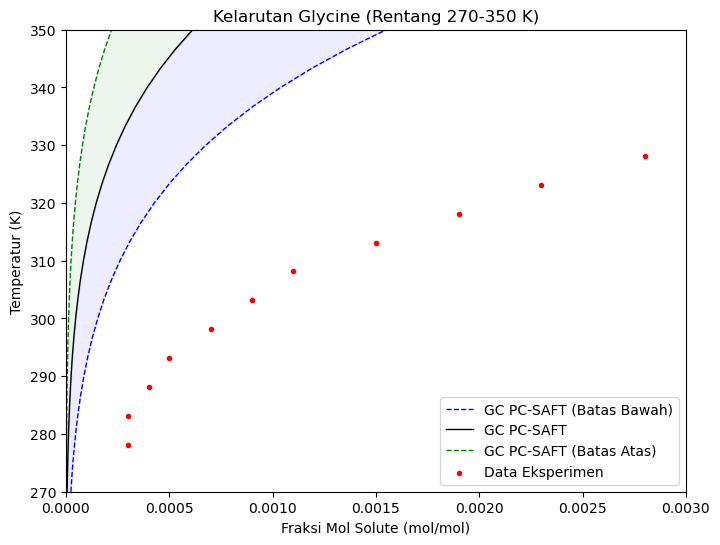

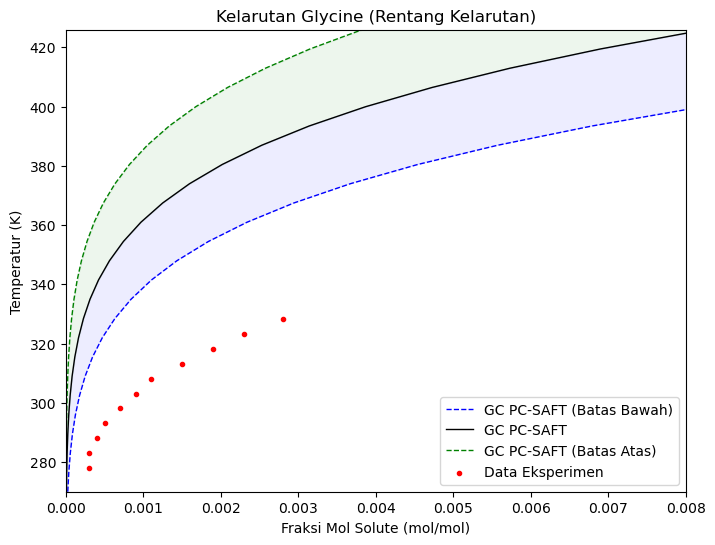

In [26]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_etanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.003)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.008)
    plt.ylim(270.0, model2_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [27]:
aard_p   = calculate_AAD(model2_low, "sol_glycine_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000042      86.1359 
283.1500    0.000300      0.000057      80.9192 
288.1500    0.000400      0.000078      80.5470 
293.1500    0.000500      0.000105      79.0919 
298.1500    0.000700      0.000139      80.1575 
303.1500    0.000900      0.000183      79.7100 
308.1500    0.001100      0.000238      78.3919 
313.1500    0.001500      0.000306      79.5697 
318.1500    0.001900      0.000392      79.3916 
323.1500    0.002300      0.000496      78.4341 
328.1500    0.002800      0.000623      77.7420 
AARD = 80.0083%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


80.00825449859126

In [28]:
aard_p   = calculate_AAD(model2_mid, "sol_glycine_etanol.csv", solubility_gcmid)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000011      96.3431 
283.1500    0.000300      0.000016      94.7855 
288.1500    0.000400      0.000022      94.4988 
293.1500    0.000500      0.000031      93.8891 
298.1500    0.000700      0.000042      94.0129 
303.1500    0.000900      0.000057      93.6869 
308.1500    0.001100      0.000076      93.0743 
313.1500    0.001500      0.000101      93.2616 
318.1500    0.001900      0.000133      93.0123 
323.1500    0.002300      0.000173      92.4899 
328.1500    0.002800      0.000223      92.0466 
AARD = 93.7365%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


93.73645667465843

In [29]:
aard_p   = calculate_AAD(model2_up, "sol_glycine_etanol.csv", solubility_gcup)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000003      99.1268 
283.1500    0.000300      0.000004      98.7098 
288.1500    0.000400      0.000006      98.5915 
293.1500    0.000500      0.000008      98.3827 
298.1500    0.000700      0.000011      98.3640 
303.1500    0.000900      0.000016      98.2207 
308.1500    0.001100      0.000022      97.9889 
313.1500    0.001500      0.000030      97.9860 
318.1500    0.001900      0.000041      97.8523 
323.1500    0.002300      0.000055      97.6286 
328.1500    0.002800      0.000072      97.4221 
AARD = 98.2067%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


98.2066735147825

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [37]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_held,0.113903
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
glycine_held,H,glycine_held,e,3012.118,0.267058
ethanol,H,glycine_held,e,2832.759,0.088581
ethanol,e,glycine_held,H,2832.759,0.088581
"""
components = ["ethanol", "glycine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[198.24 192.71692880569157; 192.71692880569157 238.6085]
[3.1771e-10 2.69555e-10; 2.69555e-10 2.214e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2653.4, 2832.759, 2832.759, 3012.118]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.032384, 0.088581, 0.088581, 0.267058]
kij = 0.11390299999999998
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          8.95429e-6
   2 │      279.583        1.54723e-5
   3 │      289.167        2.56567e-5
   4 │      298.75         4.09943e-5
   5 │      308.333        6.33353e-5
   6 │      317.917        9.49071e-5
   7 │      327.5          0.000138307
   8 │      337.083        0.000196473
   9 │      346.667        0.000272624
  10 │      356.25         0.000370176
  11 │      365.833        0.000492623
  12 │      375.417        0.000643382
  13 │      385.0          0.000825599
  14 │      394.583        0.0010419
  15 │      404.167        0.00129409
  16 │      413.75         0.00158272
  17 │      423.333        0.00190657
  18 │      432.917        0.0022619
  19 │      442.5          0.00264122
  20 │      452.083        0.00303148
  21 │      461.667        0.00341051
  22 │      471.25         0.

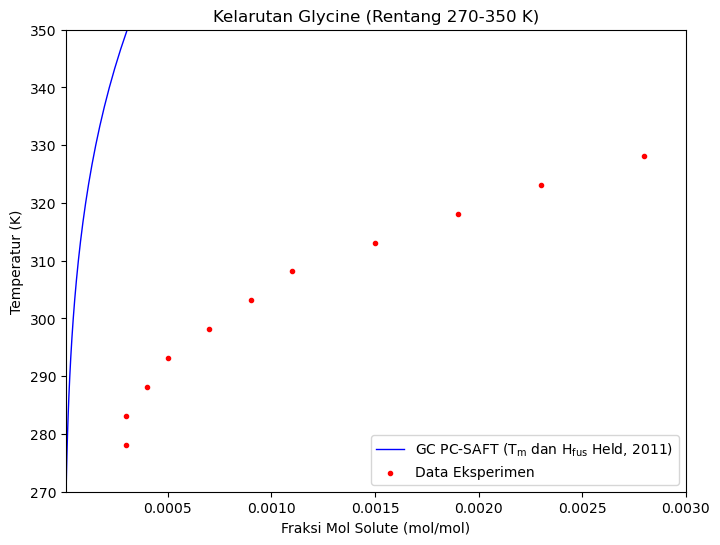

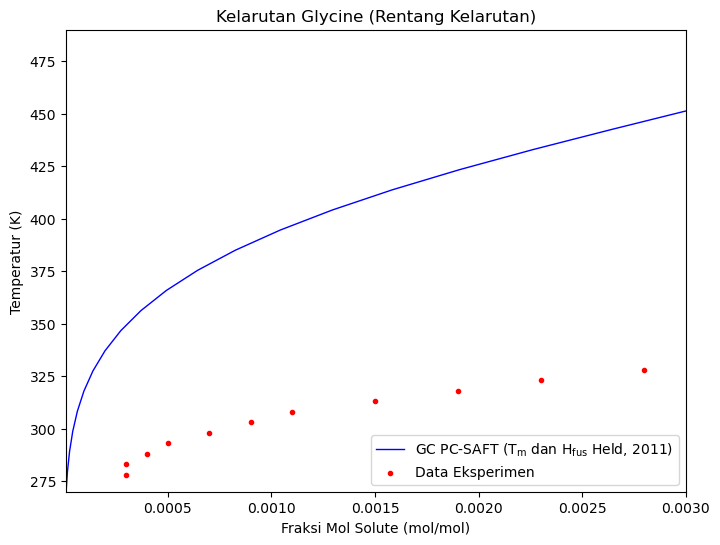

In [44]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_etanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(8e-6, 0.003)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., 500., 25)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(8e-6, 0.003)
    plt.ylim(270.0, 490.)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [45]:
aard_p   = calculate_AAD(model3, "sol_glycine_etanol.csv", solubility_held)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000014      95.2347 
283.1500    0.000300      0.000019      93.7458 
288.1500    0.000400      0.000024      93.9098 
293.1500    0.000500      0.000031      93.7383 
298.1500    0.000700      0.000040      94.3072 
303.1500    0.000900      0.000050      94.4160 
308.1500    0.001100      0.000063      94.2883 
313.1500    0.001500      0.000078      94.8070 
318.1500    0.001900      0.000096      94.9573 
323.1500    0.002300      0.000117      94.9147 
328.1500    0.002800      0.000142      94.9375 
AARD = 94.4779%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


94.47785904278412

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [46]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0.054
ethanol,glycine_gcmid,0.054
ethanol,glycine_gcup,0.054
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
"""
components_low = ["ethanol", "glycine_gclow"]
components_mid = ["ethanol", "glycine_gcmid"]
components_up = ["ethanol", "glycine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000116106  2.88048e-5   6.47155e-6
   2 │      276.498  0.00017161   4.4687e-5    1.05404e-5
   3 │      282.997  0.000248589  6.77843e-5   1.67474e-5
   4 │      289.495  0.000353418  0.000100688  2.60021e-5
   5 │      295.993  0.000493776  0.000146668  3.95095e-5
   6 │      302.492  0.000678771  0.000209781  5.88351e-5
   7 │      308.99   0.000919074  0.00029497   8.59734e-5
   8 │      315.489  0.00122704   0.000408176  0.000123422
   9 │      321.987  0.00161681   0.000556427  0.000174257
  10 │      328.485  0.00210448   0.000747936  0.000242205
  11 │      334.984  0.00270819   0.000992182  0.000331717
  12 │      341.482  0.00344835   0.00129999   0.00044803
  13 │      347.981  0.00434782   0.00168358   0.000597229
  14 │      3

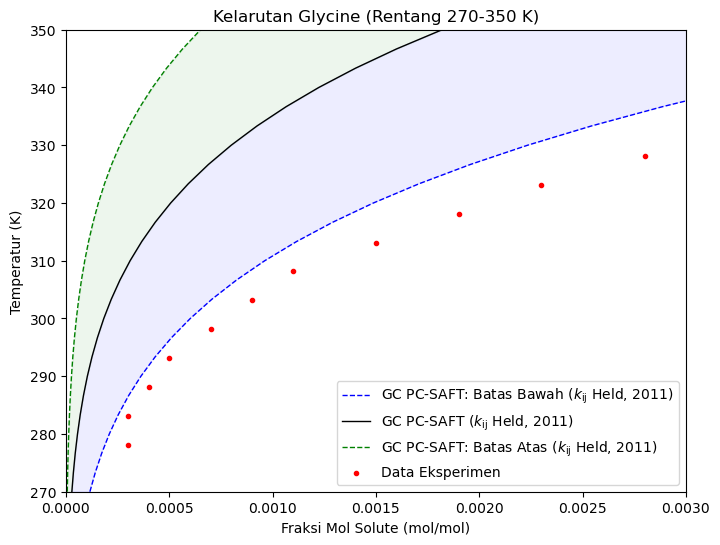

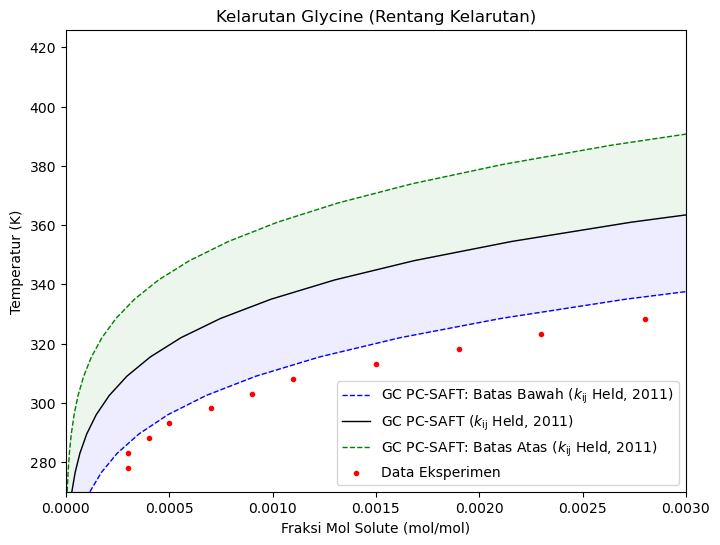

In [47]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_etanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.003)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.003)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [48]:
aard_p   = calculate_AAD(model4_low, "sol_glycine_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000189      37.0307 
283.1500    0.000300      0.000251      16.4291 
288.1500    0.000400      0.000329      17.7307 
293.1500    0.000500      0.000427      14.5123 
298.1500    0.000700      0.000550      21.4677 
303.1500    0.000900      0.000700      22.1780 
308.1500    0.001100      0.000884      19.5934 
313.1500    0.001500      0.001108      26.1625 
318.1500    0.001900      0.001376      27.5839 
323.1500    0.002300      0.001696      26.2436 
328.1500    0.002800      0.002077      25.8345 
AARD = 23.1606%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


23.160578520898735

In [49]:
aard_p   = calculate_AAD(model4_mid, "sol_glycine_etanol.csv", solubility_gcmid)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000050      83.4061 
283.1500    0.000300      0.000068      77.1880 
288.1500    0.000400      0.000093      76.7693 
293.1500    0.000500      0.000125      75.0602 
298.1500    0.000700      0.000165      76.3587 
303.1500    0.000900      0.000217      75.8542 
308.1500    0.001100      0.000283      74.3169 
313.1500    0.001500      0.000364      75.7473 
318.1500    0.001900      0.000464      75.5676 
323.1500    0.002300      0.000587      74.4667 
328.1500    0.002800      0.000737      73.6840 
AARD = 76.2199%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


76.21991666422578

In [50]:
aard_p   = calculate_AAD(model4_up, "sol_glycine_etanol.csv", solubility_gcup)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000012      96.0387 
283.1500    0.000300      0.000017      94.3578 
288.1500    0.000400      0.000024      94.0545 
293.1500    0.000500      0.000033      93.4031 
298.1500    0.000700      0.000045      93.5444 
303.1500    0.000900      0.000061      93.2011 
308.1500    0.001100      0.000082      92.5507 
313.1500    0.001500      0.000109      92.7615 
318.1500    0.001900      0.000142      92.5038 
323.1500    0.002300      0.000185      91.9547 
328.1500    0.002800      0.000238      91.4924 
AARD = 93.2603%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


93.26025400599674

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [53]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0
ethanol,glycine_gcmid,0
ethanol,glycine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
"""
components_low = ["ethanol", "glycine_gclow"]
components_mid = ["ethanol", "glycine_gcmid"]
components_up = ["ethanol", "glycine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000484314  0.000119906  2.69251e-5
   2 │      276.498  0.000684681  0.000177796  4.19059e-5
   3 │      282.997  0.000950857  0.000258324  6.3758e-5
   4 │      289.495  0.00129892   0.000368284  9.49732e-5
   5 │      295.993  0.00174752   0.000515869  0.000138702
   6 │      302.492  0.00231812   0.000710813  0.000198856
   7 │      308.99   0.00303521   0.000964513  0.000280204
   8 │      315.489  0.00392667   0.00129016   0.000388474
   9 │      321.987  0.00502419   0.00170287   0.000530437
  10 │      328.485  0.00636391   0.00221977   0.000713987
  11 │      334.984  0.00798727   0.00286019   0.000948208
  12 │      341.482  0.00994232   0.00364581   0.00124343
  13 │      347.981  0.0122856    0.00460086   0.00161126
  14 │      

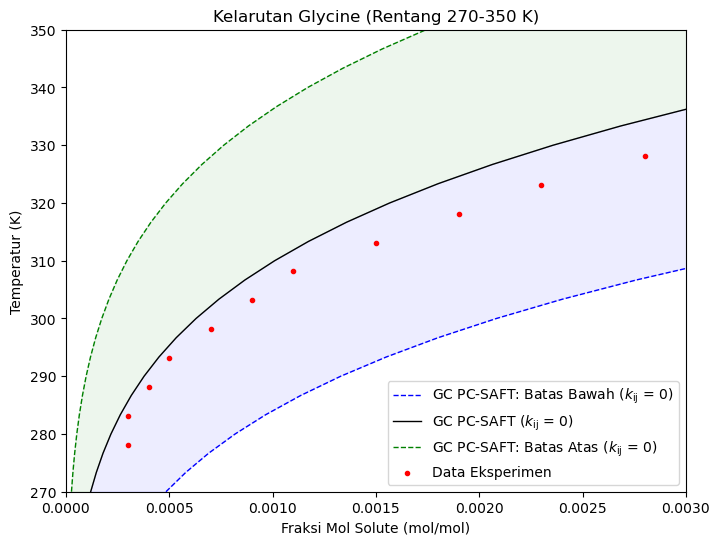

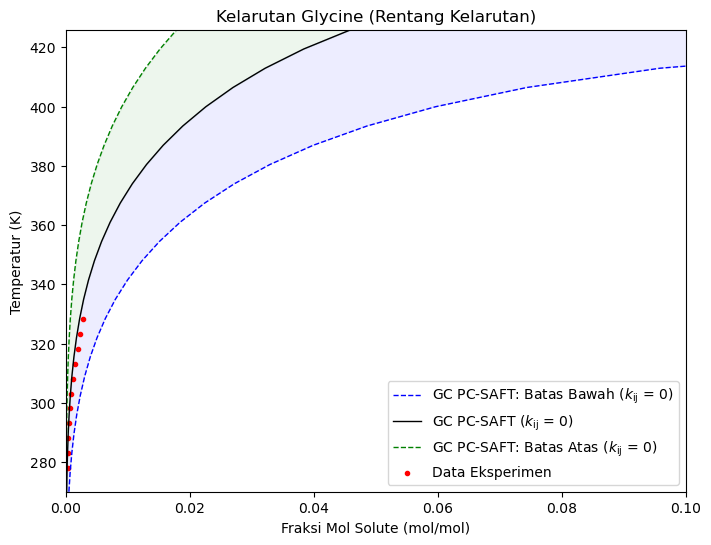

In [60]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_etanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.003)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.1)
    plt.ylim(270.0, model5_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [61]:
aard_p   = calculate_AAD(model5_low, "sol_glycine_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000746      148.5001
283.1500    0.000300      0.000958      219.3513
288.1500    0.000400      0.001219      204.8191
293.1500    0.000500      0.001538      207.5096
298.1500    0.000700      0.001922      174.6017
303.1500    0.000900      0.002384      164.8486
308.1500    0.001100      0.002933      166.6634
313.1500    0.001500      0.003584      138.9237
318.1500    0.001900      0.004349      128.9101
323.1500    0.002300      0.005245      128.0453
328.1500    0.002800      0.006288      124.5789
AARD = 164.2502%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


164.25015840074482

In [62]:
aard_p   = calculate_AAD(model5_mid, "sol_glycine_etanol.csv", solubility_gcmid)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000196      34.7097 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


283.1500    0.000300      0.000261      13.1505 
288.1500    0.000400      0.000343      14.3183 
293.1500    0.000500      0.000446      10.7853 
298.1500    0.000700      0.000575      17.8877 
303.1500    0.000900      0.000734      18.4860 
308.1500    0.001100      0.000928      15.6403 
313.1500    0.001500      0.001164      22.4152 
318.1500    0.001900      0.001448      23.8036 
323.1500    0.002300      0.001787      22.2959 
328.1500    0.002800      0.002190      21.7769 
AARD = 19.5699%


19.569932996433558

In [63]:
aard_p   = calculate_AAD(model5_up, "sol_glycine_etanol.csv", solubility_gcup)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000047      84.4266 
283.1500    0.000300      0.000064      78.5416 
288.1500    0.000400      0.000088      78.1001 
293.1500    0.000500      0.000118      76.4408 
298.1500    0.000700      0.000157      77.6247 
303.1500    0.000900      0.000206      77.1064 
308.1500    0.001100      0.000268      75.6089 
313.1500    0.001500      0.000346      76.9329 
318.1500    0.001900      0.000442      76.7306 
323.1500    0.002300      0.000560      75.6528 
328.1500    0.002800      0.000703      74.8801 
AARD = 77.4587%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


77.4586876971501

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [64]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0.114928718
ethanol,glycine_gcmid,0.114928718
ethanol,glycine_gcup,0.114928718
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
"""
components_low = ["ethanol", "glycine_gclow"]
components_mid = ["ethanol", "glycine_gcmid"]
components_up = ["ethanol", "glycine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    2.33838e-5   5.80482e-6   1.30437e-6
   2 │      276.498  3.6362e-5    9.47672e-6   2.23581e-6
   3 │      282.997  5.52824e-5   1.50919e-5   3.72999e-6
   4 │      289.495  8.23023e-5   2.3485e-5    6.0677e-6
   5 │      295.993  0.000120155  3.57657e-5   9.64085e-6
   6 │      302.492  0.000172245  5.33814e-5   1.49847e-5
   7 │      308.99   0.000242741  7.81849e-5   2.28154e-5
   8 │      315.489  0.000336675  0.000112507  3.40732e-5
   9 │      321.987  0.000460035  0.000159233  4.99705e-5
  10 │      328.485  0.000619855  0.000221881  7.20438e-5
  11 │      334.984  0.000824304  0.000304679  0.00010221
  12 │      341.482  0.00108277   0.000412639  0.000142822
  13 │      347.981  0.00140592   0.000551629  0.000196731
  14 │      354.4

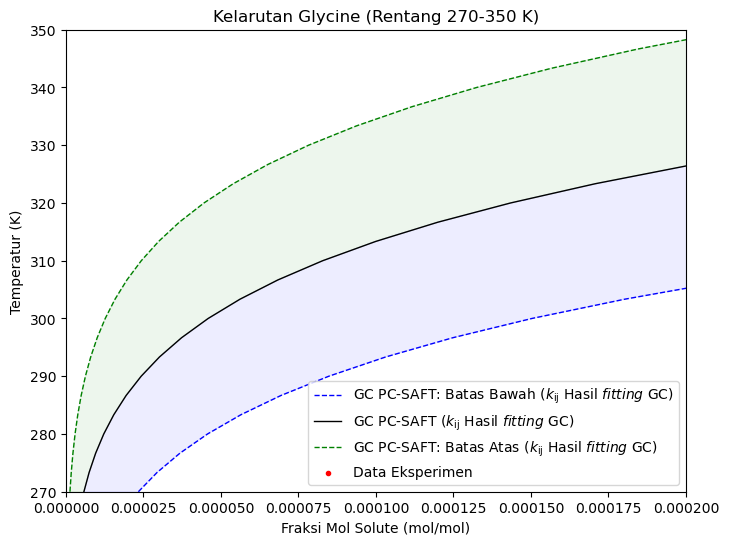

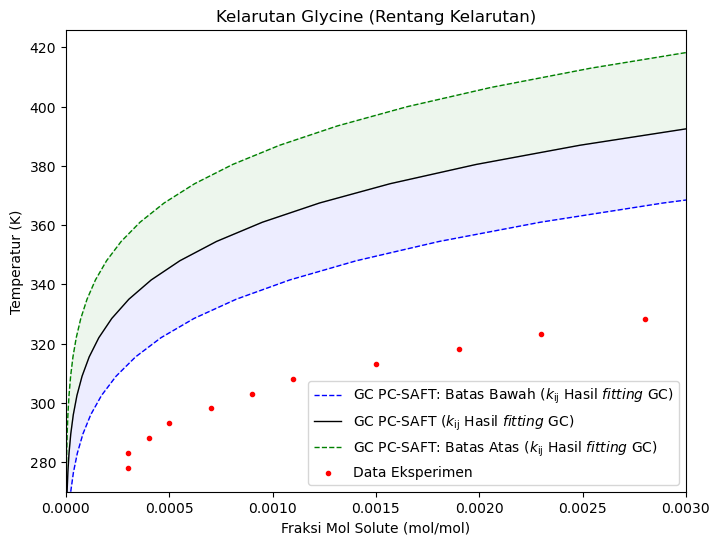

In [66]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_etanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.0002)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.003)
    plt.ylim(270.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_glycine_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [67]:
aard_p   = calculate_AAD(model6_low, "sol_glycine_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000041      86.4896 
283.1500    0.000300      0.000056      81.3944 
288.1500    0.000400      0.000076      81.0201 
293.1500    0.000500      0.000102      79.5885 
298.1500    0.000700      0.000136      80.6179 
303.1500    0.000900      0.000178      80.1700 
308.1500    0.001100      0.000232      78.8707 
313.1500    0.001500      0.000300      80.0123 
318.1500    0.001900      0.000383      79.8282 
323.1500    0.002300      0.000486      78.8809 
328.1500    0.002800      0.000611      78.1932 
AARD = 80.4605%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


80.46053856505841

In [68]:
aard_p   = calculate_AAD(model6_mid, "sol_glycine_etanol.csv", solubility_gcmid)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000011      96.4364 
283.1500    0.000300      0.000015      94.9153 
288.1500    0.000400      0.000021      94.6326 
293.1500    0.000500      0.000030      94.0341 
298.1500    0.000700      0.000041      94.1517 
303.1500    0.000900      0.000056      93.8298 
308.1500    0.001100      0.000074      93.2276 
313.1500    0.001500      0.000099      93.4073 
318.1500    0.001900      0.000130      93.1600 
323.1500    0.002300      0.000169      92.6451 
328.1500    0.002800      0.000218      92.2073 
AARD = 93.8770%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


93.8770302669244

In [69]:
aard_p   = calculate_AAD(model6_up, "sol_glycine_etanol.csv", solubility_gcup)


=== AAD: sol_glycine_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
278.1500    0.000300      0.000003      99.1491 
283.1500    0.000300      0.000004      98.7420 
288.1500    0.000400      0.000005      98.6257 
293.1500    0.000500      0.000008      98.4211 
298.1500    0.000700      0.000011      98.4019 
303.1500    0.000900      0.000016      98.2610 
308.1500    0.001100      0.000022      98.0334 
313.1500    0.001500      0.000030      98.0295 
318.1500    0.001900      0.000040      97.8977 
323.1500    0.002300      0.000053      97.6775 
328.1500    0.002800      0.000071      97.4741 
AARD = 98.2466%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


98.24663623428408